# Plot Average Returns: Fixed Alpha vs Changing Alpha

Compare the performance of SAC with fixed temperature coefficient (α) vs learnable temperature across all seeds.

## Import Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Load Data from Multiple Seeds

In [20]:
# Define base path
base_path = Path('./exp/custom')

# Load data for both conditions
fixed_alpha_data = []
changing_alpha_data = []

# Load fixed_alpha data
fixed_alpha_path = base_path / 'fixed_alpha'
for seed_dir in sorted(fixed_alpha_path.glob('seed_*')):
    eval_csv = seed_dir / '0' / 'eval.csv'
    if eval_csv.exists():
        df = pd.read_csv(eval_csv)
        fixed_alpha_data.append(df)
        print(f"Loaded: {seed_dir.name} - {len(df)} evaluations")

# Load changing_alpha data
changing_alpha_path = base_path / 'changing_alpha'
for seed_dir in sorted(changing_alpha_path.glob('seed_*')):
    eval_csv = seed_dir / '0' / 'eval.csv'
    if eval_csv.exists():
        df = pd.read_csv(eval_csv)
        changing_alpha_data.append(df)
        print(f"Loaded: {seed_dir.name} - {len(df)} evaluations")

print(f"\nTotal fixed_alpha runs: {len(fixed_alpha_data)}")
print(f"Total changing_alpha runs: {len(changing_alpha_data)}")

Loaded: seed_0 - 51 evaluations
Loaded: seed_10 - 51 evaluations
Loaded: seed_11 - 51 evaluations
Loaded: seed_12 - 51 evaluations
Loaded: seed_15 - 51 evaluations
Loaded: seed_21 - 51 evaluations
Loaded: seed_31 - 51 evaluations
Loaded: seed_32 - 51 evaluations
Loaded: seed_42 - 51 evaluations
Loaded: seed_44 - 51 evaluations
Loaded: seed_52 - 51 evaluations
Loaded: seed_63 - 51 evaluations
Loaded: seed_8 - 51 evaluations
Loaded: seed_90 - 51 evaluations
Loaded: seed_98 - 51 evaluations
Loaded: seed_0 - 51 evaluations
Loaded: seed_10 - 51 evaluations
Loaded: seed_11 - 51 evaluations
Loaded: seed_12 - 51 evaluations
Loaded: seed_15 - 51 evaluations
Loaded: seed_21 - 51 evaluations
Loaded: seed_31 - 51 evaluations
Loaded: seed_32 - 51 evaluations
Loaded: seed_42 - 51 evaluations
Loaded: seed_44 - 51 evaluations
Loaded: seed_52 - 51 evaluations
Loaded: seed_63 - 51 evaluations
Loaded: seed_8 - 51 evaluations
Loaded: seed_90 - 51 evaluations
Loaded: seed_98 - 51 evaluations

Total fixed_a

## Calculate Average Returns Across Seeds

In [21]:
# Round steps to nearest 10k before averaging
# This reduces noise and gives cleaner evaluation curves

# Process fixed_alpha data
if fixed_alpha_data:
    for df in fixed_alpha_data:
        df['step_rounded'] = (df['step'] / 10000).round() * 10000
    
    fixed_alpha_combined = pd.concat(fixed_alpha_data, ignore_index=False)
    fixed_alpha_mean = fixed_alpha_combined.groupby('step_rounded')['episode_reward'].mean()
    fixed_alpha_std = fixed_alpha_combined.groupby('step_rounded')['episode_reward'].std()
    fixed_alpha_count = fixed_alpha_combined.groupby('step_rounded')['episode_reward'].count()
    fixed_alpha_sem = fixed_alpha_std / np.sqrt(fixed_alpha_count)  # Standard error of mean
else:
    fixed_alpha_mean = pd.Series()
    fixed_alpha_sem = pd.Series()

# Process changing_alpha data
if changing_alpha_data:
    for df in changing_alpha_data:
        df['step_rounded'] = (df['step'] / 10000).round() * 10000
    
    changing_alpha_combined = pd.concat(changing_alpha_data, ignore_index=False)
    changing_alpha_mean = changing_alpha_combined.groupby('step_rounded')['episode_reward'].mean()
    changing_alpha_std = changing_alpha_combined.groupby('step_rounded')['episode_reward'].std()
    changing_alpha_count = changing_alpha_combined.groupby('step_rounded')['episode_reward'].count()
    changing_alpha_sem = changing_alpha_std / np.sqrt(changing_alpha_count)
else:
    changing_alpha_mean = pd.Series()
    changing_alpha_sem = pd.Series()

print("Fixed Alpha Statistics (rounded to 10k steps):")
print(f"  Mean at first eval: {fixed_alpha_mean.iloc[0]:.2f}")
print(f"  Mean at last eval: {fixed_alpha_mean.iloc[-1]:.2f}")
print(f"  Number of evaluation points: {len(fixed_alpha_mean)}")

print("\nChanging Alpha Statistics (rounded to 10k steps):")
print(f"  Mean at first eval: {changing_alpha_mean.iloc[0]:.2f}")
print(f"  Mean at last eval: {changing_alpha_mean.iloc[-1]:.2f}")
print(f"  Number of evaluation points: {len(changing_alpha_mean)}")

Fixed Alpha Statistics (rounded to 10k steps):
  Mean at first eval: -204.35
  Mean at last eval: 58.66
  Number of evaluation points: 51

Changing Alpha Statistics (rounded to 10k steps):
  Mean at first eval: -203.30
  Mean at last eval: 91.77
  Number of evaluation points: 51


## Plot Comparison: Average Returns vs Timesteps

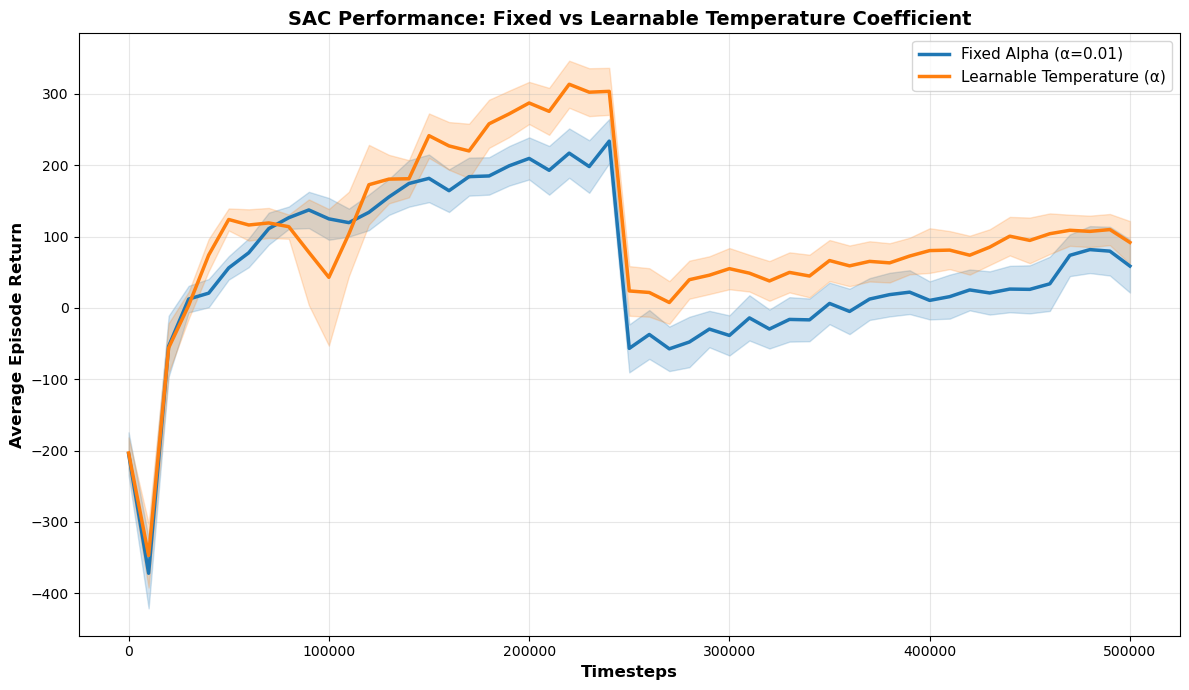

Plot saved as 'comparison_fixed_vs_changing_alpha.png'


In [22]:
plt.figure(figsize=(12, 7))

# Plot fixed_alpha
if len(fixed_alpha_mean) > 0:
    plt.plot(fixed_alpha_mean.index, fixed_alpha_mean.values, 
             label='Fixed Alpha (α=0.01)', linewidth=2.5, color='#1f77b4')
    plt.fill_between(fixed_alpha_mean.index, 
                      fixed_alpha_mean.values - fixed_alpha_sem.values,
                      fixed_alpha_mean.values + fixed_alpha_sem.values,
                      alpha=0.2, color='#1f77b4')

# Plot changing_alpha
if len(changing_alpha_mean) > 0:
    plt.plot(changing_alpha_mean.index, changing_alpha_mean.values,
             label='Learnable Temperature (α)', linewidth=2.5, color='#ff7f0e')
    plt.fill_between(changing_alpha_mean.index,
                      changing_alpha_mean.values - changing_alpha_sem.values,
                      changing_alpha_mean.values + changing_alpha_sem.values,
                      alpha=0.2, color='#ff7f0e')

plt.xlabel('Timesteps', fontsize=12, fontweight='bold')
plt.ylabel('Average Episode Return', fontsize=12, fontweight='bold')
plt.title('SAC Performance: Fixed vs Learnable Temperature Coefficient', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_fixed_vs_changing_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'comparison_fixed_vs_changing_alpha.png'")

## Summary Statistics

In [23]:
# Create summary table
summary_data = {
    'Condition': ['Fixed Alpha (α=0.01)', 'Learnable Temperature'],
    'First Eval Return': [
        f"{fixed_alpha_mean.iloc[0]:.2f}" if len(fixed_alpha_mean) > 0 else "N/A",
        f"{changing_alpha_mean.iloc[0]:.2f}" if len(changing_alpha_mean) > 0 else "N/A"
    ],
    'Final Eval Return': [
        f"{fixed_alpha_mean.iloc[-1]:.2f}" if len(fixed_alpha_mean) > 0 else "N/A",
        f"{changing_alpha_mean.iloc[-1]:.2f}" if len(changing_alpha_mean) > 0 else "N/A"
    ],
    'Improvement': [
        f"{fixed_alpha_mean.iloc[-1] - fixed_alpha_mean.iloc[0]:.2f}" if len(fixed_alpha_mean) > 0 else "N/A",
        f"{changing_alpha_mean.iloc[-1] - changing_alpha_mean.iloc[0]:.2f}" if len(changing_alpha_mean) > 0 else "N/A"
    ],
    'Num Seeds': [len(fixed_alpha_data), len(changing_alpha_data)]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


SUMMARY STATISTICS
            Condition First Eval Return Final Eval Return Improvement  Num Seeds
 Fixed Alpha (α=0.01)           -204.35             58.66      263.02         15
Learnable Temperature           -203.30             91.77      295.07         15


In [31]:
# Process data to get 20-episode average returns every 10K steps for all experiments

def process_eval_data_by_checkpoint(df, episodes_per_eval=20):
    """
    Round steps to nearest 10K, then group episodes by 10K step checkpoints 
    and compute average return for each checkpoint.
    Returns: dataframe with columns [checkpoint_step, avg_return, num_episodes]
    """
    # Round each step to nearest 10k
    df = df.copy()
    df['step_rounded'] = (df['step'] / 10000).round() * 10000
    
    # Group by rounded step and compute statistics
    results = []
    for step_rounded in sorted(df['step_rounded'].unique()):
        episodes_at_checkpoint = df[df['step_rounded'] == step_rounded]
        
        if len(episodes_at_checkpoint) > 0:
            # Take first episodes_per_eval episodes in this checkpoint
            episodes_at_checkpoint = episodes_at_checkpoint.head(episodes_per_eval)
            avg_return = episodes_at_checkpoint['episode_reward'].mean()
            results.append({
                'checkpoint_step': step_rounded,
                'avg_return': avg_return,
                'num_episodes': len(episodes_at_checkpoint),
                'std_return': episodes_at_checkpoint['episode_reward'].std()
            })
    
    return pd.DataFrame(results)

# Process fixed_alpha experiments
fixed_alpha_checkpoint_data = []
print("Fixed Alpha (α=0.01) - Processing by 10K step checkpoints:")
for i, df in enumerate(fixed_alpha_data):
    seed_name = sorted(fixed_alpha_path.glob('seed_*'))[i].name
    checkpoint_df = process_eval_data_by_checkpoint(df, episodes_per_eval=20)
    checkpoint_df['seed'] = seed_name
    fixed_alpha_checkpoint_data.append(checkpoint_df)
    print(f"  {seed_name}: {len(checkpoint_df)} checkpoints")

fixed_alpha_checkpoint_combined = pd.concat(fixed_alpha_checkpoint_data, ignore_index=True)

# Process changing_alpha experiments
changing_alpha_checkpoint_data = []
print("\nLearnable Temperature (α) - Processing by 10K step checkpoints:")
for i, df in enumerate(changing_alpha_data):
    seed_name = sorted(changing_alpha_path.glob('seed_*'))[i].name
    checkpoint_df = process_eval_data_by_checkpoint(df, episodes_per_eval=20)
    checkpoint_df['seed'] = seed_name
    changing_alpha_checkpoint_data.append(checkpoint_df)
    print(f"  {seed_name}: {len(checkpoint_df)} checkpoints")

changing_alpha_checkpoint_combined = pd.concat(changing_alpha_checkpoint_data, ignore_index=True)

# Compute statistics across seeds for each condition
fixed_alpha_by_step = fixed_alpha_checkpoint_combined.groupby('checkpoint_step')['avg_return'].agg(['mean', 'std', 'count']).reset_index()
fixed_alpha_by_step['sem'] = fixed_alpha_by_step['std'] / np.sqrt(fixed_alpha_by_step['count'])

changing_alpha_by_step = changing_alpha_checkpoint_combined.groupby('checkpoint_step')['avg_return'].agg(['mean', 'std', 'count']).reset_index()
changing_alpha_by_step['sem'] = changing_alpha_by_step['std'] / np.sqrt(changing_alpha_by_step['count'])

print(f"\nFixed Alpha: {len(fixed_alpha_by_step)} checkpoints, {fixed_alpha_by_step['count'].iloc[0]:.0f} seeds per checkpoint")
print(f"Learnable Temperature: {len(changing_alpha_by_step)} checkpoints, {changing_alpha_by_step['count'].iloc[0]:.0f} seeds per checkpoint")


Fixed Alpha (α=0.01) - Processing by 10K step checkpoints:
  seed_0: 51 checkpoints
  seed_10: 51 checkpoints
  seed_11: 51 checkpoints
  seed_12: 51 checkpoints
  seed_15: 51 checkpoints
  seed_21: 51 checkpoints
  seed_31: 51 checkpoints
  seed_32: 51 checkpoints
  seed_42: 51 checkpoints
  seed_44: 51 checkpoints
  seed_52: 51 checkpoints
  seed_63: 51 checkpoints
  seed_8: 51 checkpoints
  seed_90: 51 checkpoints
  seed_98: 51 checkpoints

Learnable Temperature (α) - Processing by 10K step checkpoints:
  seed_0: 51 checkpoints
  seed_10: 51 checkpoints
  seed_11: 51 checkpoints
  seed_12: 51 checkpoints
  seed_15: 51 checkpoints
  seed_21: 51 checkpoints
  seed_31: 51 checkpoints
  seed_32: 51 checkpoints
  seed_42: 51 checkpoints
  seed_44: 51 checkpoints
  seed_52: 51 checkpoints
  seed_63: 51 checkpoints
  seed_8: 51 checkpoints
  seed_90: 51 checkpoints
  seed_98: 51 checkpoints

Fixed Alpha: 51 checkpoints, 15 seeds per checkpoint
Learnable Temperature: 51 checkpoints, 15 seed

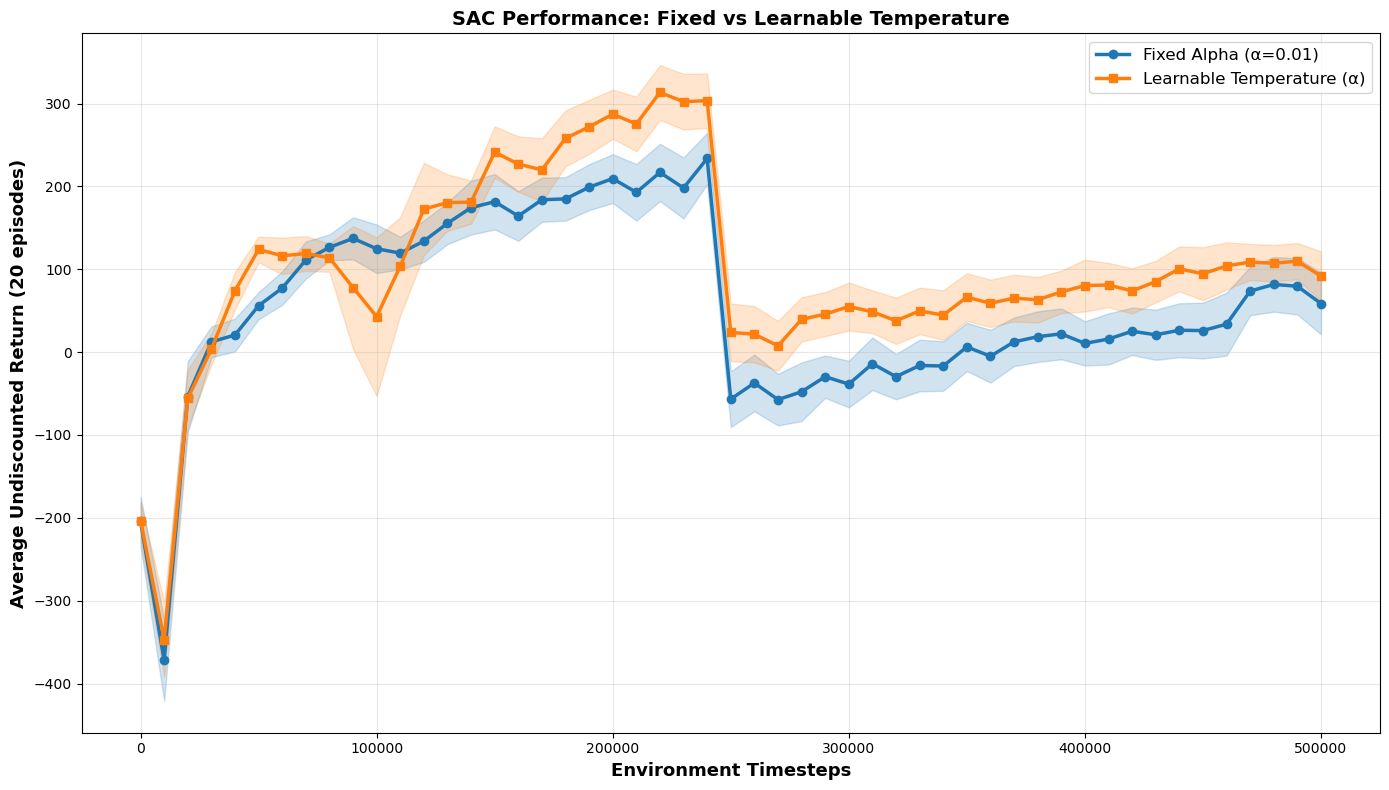

Plot saved as 'all_experiments_20episode_evaluations.png'


In [25]:
# Plot 1: Combined comparison with 20-episode evaluation windows
plt.figure(figsize=(14, 8))

# Plot fixed_alpha
plt.plot(fixed_alpha_by_step['checkpoint_step'], fixed_alpha_by_step['mean'],
         label='Fixed Alpha (α=0.01)', linewidth=2.5, color='#1f77b4', marker='o', markersize=6)
plt.fill_between(fixed_alpha_by_step['checkpoint_step'],
                  fixed_alpha_by_step['mean'] - fixed_alpha_by_step['sem'],
                  fixed_alpha_by_step['mean'] + fixed_alpha_by_step['sem'],
                  alpha=0.2, color='#1f77b4')

# Plot changing_alpha
plt.plot(changing_alpha_by_step['checkpoint_step'], changing_alpha_by_step['mean'],
         label='Learnable Temperature (α)', linewidth=2.5, color='#ff7f0e', marker='s', markersize=6)
plt.fill_between(changing_alpha_by_step['checkpoint_step'],
                  changing_alpha_by_step['mean'] - changing_alpha_by_step['sem'],
                  changing_alpha_by_step['mean'] + changing_alpha_by_step['sem'],
                  alpha=0.2, color='#ff7f0e')

plt.xlabel('Environment Timesteps', fontsize=13, fontweight='bold')
plt.ylabel('Average Undiscounted Return (20 episodes)', fontsize=13, fontweight='bold')
plt.title('SAC Performance: Fixed vs Learnable Temperature', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_experiments_20episode_evaluations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'all_experiments_20episode_evaluations.png'")


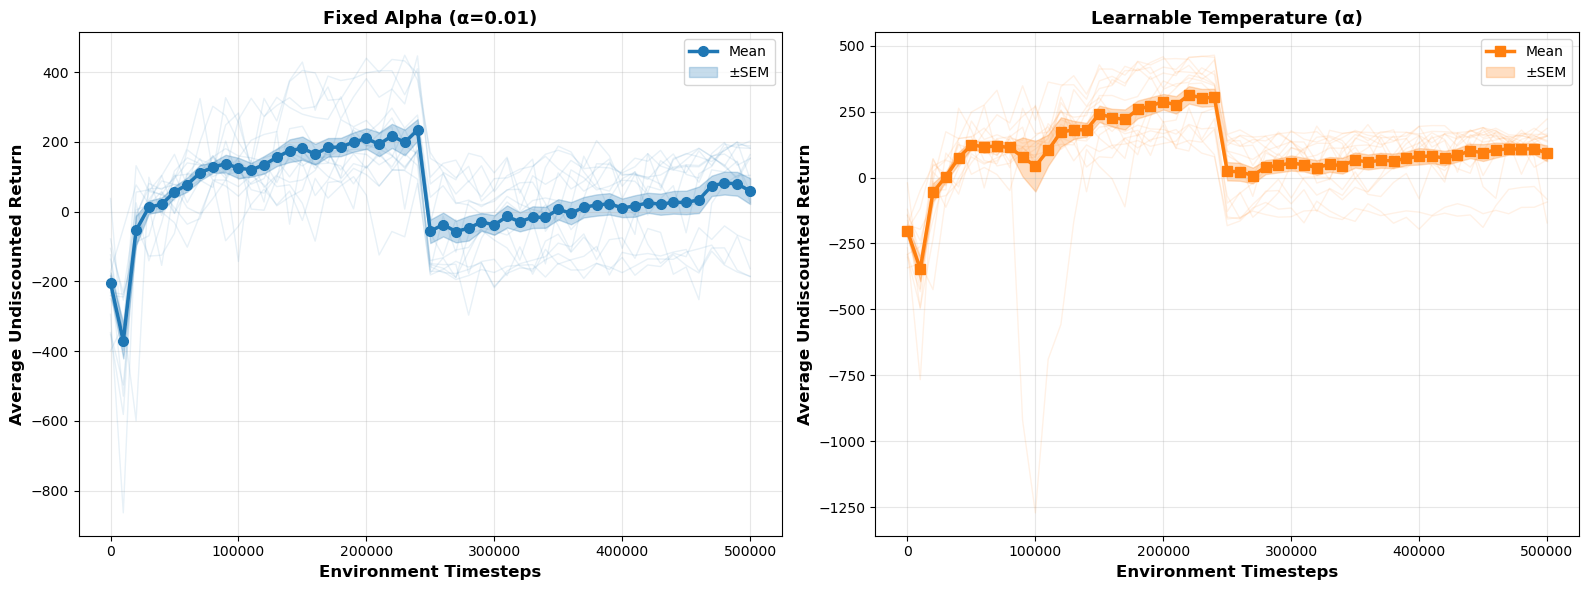

Plot saved as 'all_experiments_individual_conditions.png'


In [26]:
# Plot 2: Subplots for each condition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fixed Alpha subplot
axes[0].plot(fixed_alpha_by_step['checkpoint_step'], fixed_alpha_by_step['mean'],
             linewidth=2.5, color='#1f77b4', marker='o', markersize=7, label='Mean')
axes[0].fill_between(fixed_alpha_by_step['checkpoint_step'],
                      fixed_alpha_by_step['mean'] - fixed_alpha_by_step['sem'],
                      fixed_alpha_by_step['mean'] + fixed_alpha_by_step['sem'],
                      alpha=0.25, color='#1f77b4', label='±SEM')
axes[0].set_xlabel('Environment Timesteps', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Undiscounted Return', fontsize=12, fontweight='bold')
axes[0].set_title('Fixed Alpha (α=0.01)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Plot individual seeds as faint lines
for seed in fixed_alpha_checkpoint_combined['seed'].unique():
    seed_data = fixed_alpha_checkpoint_combined[fixed_alpha_checkpoint_combined['seed'] == seed].sort_values('checkpoint_step')
    axes[0].plot(seed_data['checkpoint_step'], seed_data['avg_return'], alpha=0.1, color='#1f77b4', linewidth=1)

# Learnable Temperature subplot
axes[1].plot(changing_alpha_by_step['checkpoint_step'], changing_alpha_by_step['mean'],
             linewidth=2.5, color='#ff7f0e', marker='s', markersize=7, label='Mean')
axes[1].fill_between(changing_alpha_by_step['checkpoint_step'],
                      changing_alpha_by_step['mean'] - changing_alpha_by_step['sem'],
                      changing_alpha_by_step['mean'] + changing_alpha_by_step['sem'],
                      alpha=0.25, color='#ff7f0e', label='±SEM')
axes[1].set_xlabel('Environment Timesteps', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Undiscounted Return', fontsize=12, fontweight='bold')
axes[1].set_title('Learnable Temperature (α)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

# Plot individual seeds as faint lines
for seed in changing_alpha_checkpoint_combined['seed'].unique():
    seed_data = changing_alpha_checkpoint_combined[changing_alpha_checkpoint_combined['seed'] == seed].sort_values('checkpoint_step')
    axes[1].plot(seed_data['checkpoint_step'], seed_data['avg_return'], alpha=0.1, color='#ff7f0e', linewidth=1)

plt.tight_layout()
plt.savefig('all_experiments_individual_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'all_experiments_individual_conditions.png'")


In [27]:
# Compute summary statistics
summary_20ep = {
    'Condition': ['Fixed Alpha (α=0.01)', 'Learnable Temperature'],
    'Num Seeds': [len(fixed_alpha_data), len(changing_alpha_data)],
    'First Checkpoint (10K)': [
        f"{fixed_alpha_by_step['mean'].iloc[0]:.2f} ± {fixed_alpha_by_step['sem'].iloc[0]:.2f}",
        f"{changing_alpha_by_step['mean'].iloc[0]:.2f} ± {changing_alpha_by_step['sem'].iloc[0]:.2f}"
    ],
    'Last Checkpoint': [
        f"{fixed_alpha_by_step['mean'].iloc[-1]:.2f} ± {fixed_alpha_by_step['sem'].iloc[-1]:.2f}",
        f"{changing_alpha_by_step['mean'].iloc[-1]:.2f} ± {changing_alpha_by_step['sem'].iloc[-1]:.2f}"
    ],
    'Max Return': [
        f"{fixed_alpha_by_step['mean'].max():.2f}",
        f"{changing_alpha_by_step['mean'].max():.2f}"
    ],
    'Num Checkpoints': [
        len(fixed_alpha_by_step),
        len(changing_alpha_by_step)
    ]
}

summary_20ep_df = pd.DataFrame(summary_20ep)
print("\n" + "="*100)
print("20-EPISODE EVALUATION SUMMARY (every 10K timesteps)")
print("="*100)
print(summary_20ep_df.to_string(index=False))
print("="*100)

# Show checkpoint details
print("\n\nFIXED ALPHA - Checkpoint Details:")
print(fixed_alpha_by_step[['checkpoint_step', 'mean', 'sem', 'count']].to_string(index=False))
print("\n\nLEARNABLE TEMPERATURE - Checkpoint Details:")
print(changing_alpha_by_step[['checkpoint_step', 'mean', 'sem', 'count']].to_string(index=False))



20-EPISODE EVALUATION SUMMARY (every 10K timesteps)
            Condition  Num Seeds First Checkpoint (10K) Last Checkpoint Max Return  Num Checkpoints
 Fixed Alpha (α=0.01)         15        -204.35 ± 30.04   58.66 ± 37.14     233.76               51
Learnable Temperature         15        -203.30 ± 21.80   91.77 ± 29.92     313.44               51


FIXED ALPHA - Checkpoint Details:
 checkpoint_step        mean       sem  count
             0.0 -204.354678 30.041160     15
         10000.0 -371.877340 49.137519     15
         20000.0  -53.698626 42.681426     15
         30000.0   12.393304 18.564621     15
         40000.0   20.703286 19.824800     15
         50000.0   56.074995 16.370840     15
         60000.0   77.297370 20.240934     15
         70000.0  111.155510 22.374169     15
         80000.0  126.459995 15.666111     15
         90000.0  137.299020 25.410191     15
        100000.0  124.813746 29.293886     15
        110000.0  119.517257 19.650841     15
        12000

In [36]:
# Compare pre-flip (+200 bonus) vs post-flip (-100 bonus) behavior
# Flip occurs at step 250,000

reward_flip_step = 250000

# Split data for each condition
fixed_alpha_pre_flip = fixed_alpha_by_step[fixed_alpha_by_step['checkpoint_step'] <= reward_flip_step]
fixed_alpha_post_flip = fixed_alpha_by_step[fixed_alpha_by_step['checkpoint_step'] > reward_flip_step]

changing_alpha_pre_flip = changing_alpha_by_step[changing_alpha_by_step['checkpoint_step'] <= reward_flip_step]
changing_alpha_post_flip = changing_alpha_by_step[changing_alpha_by_step['checkpoint_step'] > reward_flip_step]

# Compute metrics for pre vs post flip
metrics_comparison = {
    'Condition': ['Fixed Alpha (pre-flip)', 'Fixed Alpha (post-flip)', 
                  'Learnable Temp (pre-flip)', 'Learnable Temp (post-flip)'],
    'Phase': ['Before +200→-100', 'After +200→-100', 'Before +200→-100', 'After +200→-100'],
    'Timestep Range': ['0-250K', '250K-500K', '0-250K', '250K-500K'],
    'Mean Return': [
        f"{fixed_alpha_pre_flip['mean'].mean():.2f}",
        f"{fixed_alpha_post_flip['mean'].mean():.2f}",
        f"{changing_alpha_pre_flip['mean'].mean():.2f}",
        f"{changing_alpha_post_flip['mean'].mean():.2f}"
    ],
    'Peak Return': [
        f"{fixed_alpha_pre_flip['mean'].max():.2f}",
        f"{fixed_alpha_post_flip['mean'].max():.2f}",
        f"{changing_alpha_pre_flip['mean'].max():.2f}",
        f"{changing_alpha_post_flip['mean'].max():.2f}"
    ],
}

metrics_df = pd.DataFrame(metrics_comparison)
print("\n" + "="*110)
print("REWARD FLIP ANALYSIS: +200 Bonus (0-250K steps) → -100 Bonus (250K-500K steps)")
print("="*110)
print(metrics_df.to_string(index=False))
print("="*110)

# Calculate impact of reward flip
print("\n" + "="*110)
print("QUANTITATIVE IMPACT OF REWARD FLIP")
print("="*110)
fixed_alpha_drop = fixed_alpha_pre_flip['mean'].iloc[-1] - fixed_alpha_post_flip['mean'].iloc[0]
changing_alpha_drop = changing_alpha_pre_flip['mean'].iloc[-1] - changing_alpha_post_flip['mean'].iloc[0]
print(f"Fixed Alpha:         Return drop from pre-flip end to post-flip start: {fixed_alpha_drop:.2f} points")
print(f"Learnable Temp:      Return drop from pre-flip end to post-flip start: {changing_alpha_drop:.2f} points")
print(f"Difference in drop:  {abs(changing_alpha_drop - fixed_alpha_drop):.2f} points " +
      f"({'Learnable better' if abs(changing_alpha_drop) < abs(fixed_alpha_drop) else 'Fixed alpha better'} at handling transition)")

# Calculate final recovery
fixed_alpha_final_recovery = fixed_alpha_post_flip['mean'].iloc[-1] - fixed_alpha_post_flip['mean'].iloc[0]
changing_alpha_final_recovery = changing_alpha_post_flip['mean'].iloc[-1] - changing_alpha_post_flip['mean'].iloc[0]
print(f"\nPost-flip recovery (250K→500K):")
print(f"Fixed Alpha:         {fixed_alpha_final_recovery:+.2f} points")
print(f"Learnable Temp:      {changing_alpha_final_recovery:+.2f} points")
print("="*110)



REWARD FLIP ANALYSIS: +200 Bonus (0-250K steps) → -100 Bonus (250K-500K steps)
                 Condition            Phase Timestep Range Mean Return Peak Return
    Fixed Alpha (pre-flip) Before +200→-100         0-250K       97.23      233.76
   Fixed Alpha (post-flip)  After +200→-100      250K-500K        8.80       81.72
 Learnable Temp (pre-flip) Before +200→-100         0-250K      131.83      313.44
Learnable Temp (post-flip)  After +200→-100      250K-500K       68.58      109.80

QUANTITATIVE IMPACT OF REWARD FLIP
Fixed Alpha:         Return drop from pre-flip end to post-flip start: -19.50 points
Learnable Temp:      Return drop from pre-flip end to post-flip start: 2.14 points
Difference in drop:  21.64 points (Learnable better at handling transition)

Post-flip recovery (250K→500K):
Fixed Alpha:         +95.87 points
Learnable Temp:      +70.12 points


In [41]:
# Concise summary: Key differences between Fixed Alpha and Learnable Temp
# Calculate recovery variance across seeds
fixed_alpha_recoveries = []
changing_alpha_recoveries = []

# Compute per-seed recovery values for post-flip phase
for seed in fixed_alpha_checkpoint_combined['seed'].unique():
    seed_data_post = fixed_alpha_checkpoint_combined[
        (fixed_alpha_checkpoint_combined['seed'] == seed) & 
        (fixed_alpha_checkpoint_combined['checkpoint_step'] > reward_flip_step)
    ].sort_values('checkpoint_step')
    if len(seed_data_post) >= 2:
        recovery = seed_data_post['avg_return'].iloc[-1] - seed_data_post['avg_return'].iloc[0]
        fixed_alpha_recoveries.append(recovery)

for seed in changing_alpha_checkpoint_combined['seed'].unique():
    seed_data_post = changing_alpha_checkpoint_combined[
        (changing_alpha_checkpoint_combined['seed'] == seed) & 
        (changing_alpha_checkpoint_combined['checkpoint_step'] > reward_flip_step)
    ].sort_values('checkpoint_step')
    if len(seed_data_post) >= 2:
        recovery = seed_data_post['avg_return'].iloc[-1] - seed_data_post['avg_return'].iloc[0]
        changing_alpha_recoveries.append(recovery)

# Compute statistics
fixed_alpha_recovery_mean = np.mean(fixed_alpha_recoveries)
fixed_alpha_recovery_std = np.std(fixed_alpha_recoveries)
fixed_alpha_recovery_sem = fixed_alpha_recovery_std / np.sqrt(len(fixed_alpha_recoveries))

changing_alpha_recovery_mean = np.mean(changing_alpha_recoveries)
changing_alpha_recovery_std = np.std(changing_alpha_recoveries)
changing_alpha_recovery_sem = changing_alpha_recovery_std / np.sqrt(len(changing_alpha_recoveries))

print("\n" + "="*110)
print("QUALITATIVE BEHAVIOR COMPARISON")
print("="*110)
print("\n PHASE 1 (+200 bonus, 0-250K steps)")
print(f"  Fixed Alpha:      Avg return {fixed_alpha_pre_flip['mean'].mean():.1f}, Peak {fixed_alpha_pre_flip['mean'].max():.1f}")
print(f"  Learnable Temp:   Avg return {changing_alpha_pre_flip['mean'].mean():.1f}, Peak {changing_alpha_pre_flip['mean'].max():.1f}")
print(f"  → Learnable learns {changing_alpha_pre_flip['mean'].max() - fixed_alpha_pre_flip['mean'].max():.1f} points faster")

print("TRANSITION (at 250K steps) ")
print(f"  Fixed Alpha:      Sharp drop to {fixed_alpha_post_flip['mean'].iloc[0]:.1f} ({fixed_alpha_pre_flip['mean'].iloc[-1] - fixed_alpha_post_flip['mean'].iloc[0]:.1f} point loss)")
print(f"  Learnable Temp:   Smoother drop to {changing_alpha_post_flip['mean'].iloc[0]:.1f} ({changing_alpha_pre_flip['mean'].iloc[-1] - changing_alpha_post_flip['mean'].iloc[0]:.1f} point loss)")

print("\n PHASE 2 (-100 bonus, 250K-500K steps) - ADAPTATION PHASE:")
print(f"  Fixed Alpha:      Slow recovery, ends at {fixed_alpha_post_flip['mean'].iloc[-1]:.1f}")
print(f"  Learnable Temp:   Faster stabilization, ends at {changing_alpha_post_flip['mean'].iloc[-1]:.1f}")
print(f"  → Learnable stabilizes {changing_alpha_post_flip['mean'].iloc[-1] - fixed_alpha_post_flip['mean'].iloc[-1]:.1f} points higher")

print("\n" + "="*110)
print("POST-FLIP RECOVERY ANALYSIS (with variance across seeds)")
print("="*110)
print(f"\nFixed Alpha Recovery (250K→500K):")
print(f"  Mean recovery:         {fixed_alpha_recovery_mean:+.2f} points")
print(f"  Std dev across seeds:  {fixed_alpha_recovery_std:.2f} points")
print(f"  Std error of mean:     ±{fixed_alpha_recovery_sem:.2f} points")
print(f"  95% CI:                [{fixed_alpha_recovery_mean - 1.96*fixed_alpha_recovery_sem:+.2f}, {fixed_alpha_recovery_mean + 1.96*fixed_alpha_recovery_sem:+.2f}]")
print(f"  Num seeds:             {len(fixed_alpha_recoveries)}")

print(f"\nLearnable Temperature Recovery (250K→500K):")
print(f"  Mean recovery:         {changing_alpha_recovery_mean:+.2f} points")
print(f"  Std dev across seeds:  {changing_alpha_recovery_std:.2f} points")
print(f"  Std error of mean:     ±{changing_alpha_recovery_sem:.2f} points")
print(f"  95% CI:                [{changing_alpha_recovery_mean - 1.96*changing_alpha_recovery_sem:+.2f}, {changing_alpha_recovery_mean + 1.96*changing_alpha_recovery_sem:+.2f}]")
print(f"  Num seeds:             {len(changing_alpha_recoveries)}")

recovery_diff = changing_alpha_recovery_mean - fixed_alpha_recovery_mean
combined_sem = np.sqrt(fixed_alpha_recovery_sem**2 + changing_alpha_recovery_sem**2)
print(f"\nComparison:")
print(f"  Recovery difference (Learnable - Fixed):  {recovery_diff:+.2f} ± {combined_sem:.2f}")
print(f"  Learnable recovery is {'faster' if recovery_diff > 0 else 'slower'} by {abs(recovery_diff):.2f} points (±{combined_sem:.2f})")
print("="*110)


QUALITATIVE BEHAVIOR COMPARISON

 PHASE 1 (+200 bonus, 0-250K steps)
  Fixed Alpha:      Avg return 97.2, Peak 233.8
  Learnable Temp:   Avg return 131.8, Peak 313.4
  → Learnable learns 79.7 points faster
TRANSITION (at 250K steps) 
  Fixed Alpha:      Sharp drop to -37.2 (-19.5 point loss)
  Learnable Temp:   Smoother drop to 21.7 (2.1 point loss)

 PHASE 2 (-100 bonus, 250K-500K steps) - ADAPTATION PHASE:
  Fixed Alpha:      Slow recovery, ends at 58.7
  Learnable Temp:   Faster stabilization, ends at 91.8
  → Learnable stabilizes 33.1 points higher

POST-FLIP RECOVERY ANALYSIS (with variance across seeds)

Fixed Alpha Recovery (250K→500K):
  Mean recovery:         +95.87 points
  Std dev across seeds:  131.84 points
  Std error of mean:     ±34.04 points
  95% CI:                [+29.15, +162.60]
  Num seeds:             15

Learnable Temperature Recovery (250K→500K):
  Mean recovery:         +70.12 points
  Std dev across seeds:  150.96 points
  Std error of mean:     ±38.98 poin